<a href="https://colab.research.google.com/github/shahzodjabbarov/BRAMBLE/blob/main/02_04ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
def load_housing_data():
  tarball_path = Path("datasets/housing.tgz")
  if not tarball_path.is_file():
      Path("datasets").mkdir(parents=True, exist_ok=True)
      url = "https://github.com/ageron/data/raw/main/housing.tgz"
      urllib.request.urlretrieve(url, tarball_path)
      with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="datasets", filter="data")
  return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

In [ ]:
print(housing_full)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  media

In [ ]:
import numpy as np
def shuffle_and_split_data(data, test_ratio, rng):
 shuffled_indices = rng.permutation(len(data))
 test_set_size = int(len(data) * test_ratio)
 test_indices = shuffled_indices[:test_set_size]
 train_indices = shuffled_indices[test_set_size:]
 return data.iloc[train_indices], data.iloc[test_indices]

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from pandas.plotting import scatter_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor, ColumnTransformer, make_column_selector, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import MiniBatchKMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = MiniBatchKMeans(self.n_clusters, random_state=self.random_state, n_init='auto')
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

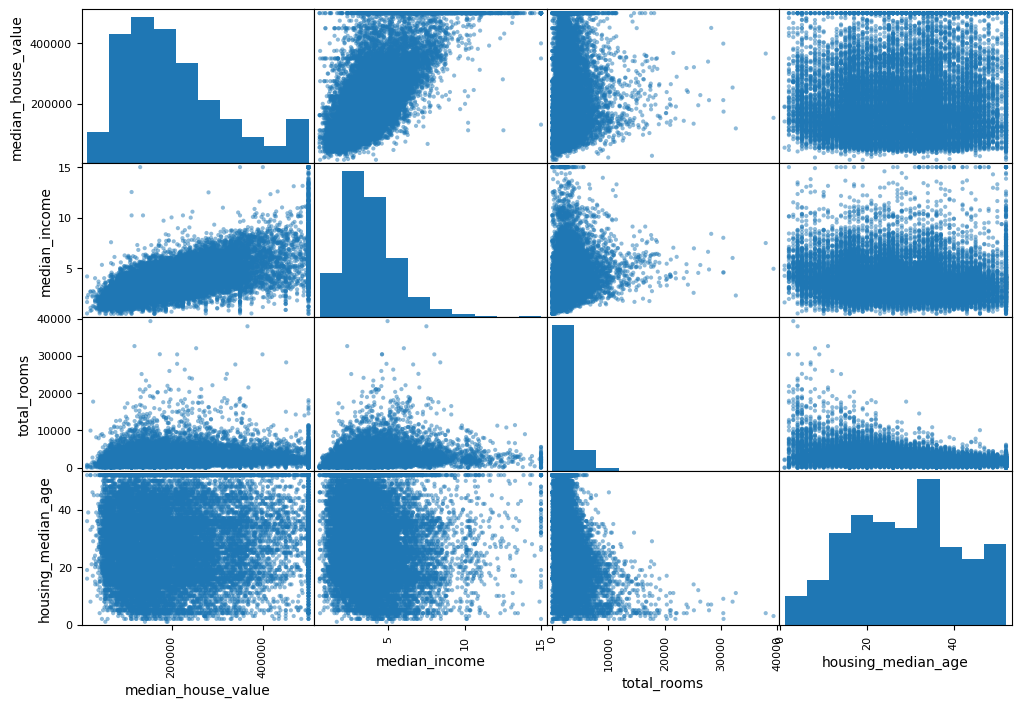

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
 "housing_median_age"]
scatter_matrix(housing_full[attributes], figsize=(12, 8))
plt.show()

In [ ]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
 bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
 labels=[1, 2, 3, 4, 5])


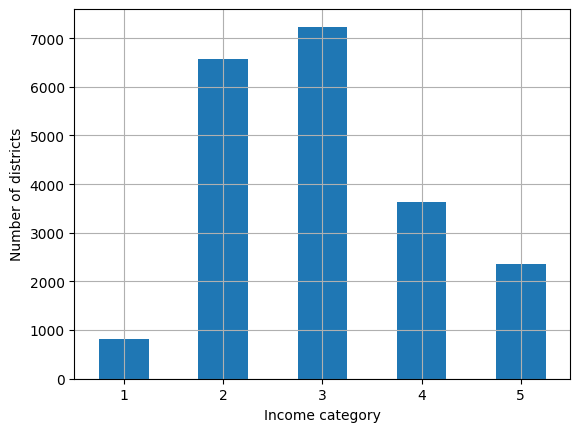

In [ ]:
cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing_full,
 housing_full["income_cat"]):
 strat_train_set_n = housing_full.iloc[train_index]
 strat_test_set_n = housing_full.iloc[test_index]
 strat_splits.append([strat_train_set_n, strat_test_set_n])


In [ ]:
strat_train_set, strat_test_set = strat_splits[0]

In [ ]:
in_set, strat_test_set = train_test_split(
 housing_full, test_size=0.2, stratify=housing_full["income_cat"],
 random_state=42)


In [ ]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [ ]:
for set_ in (strat_train_set, strat_test_set):
 set_.drop("income_cat", axis=1, inplace=True)

/tmp/ipython-input-438350011.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat", axis=1, inplace=True)


In [ ]:
housing = strat_train_set.copy()


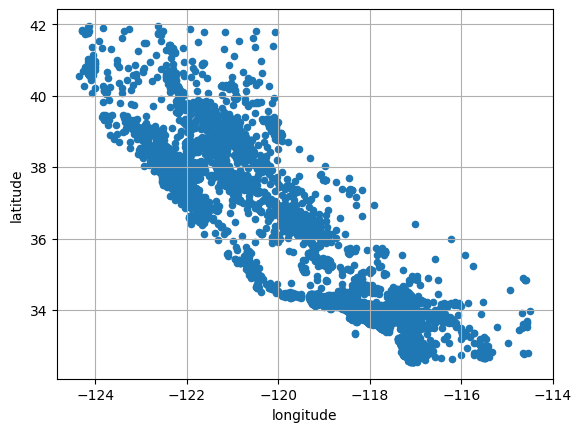

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
plt.show()

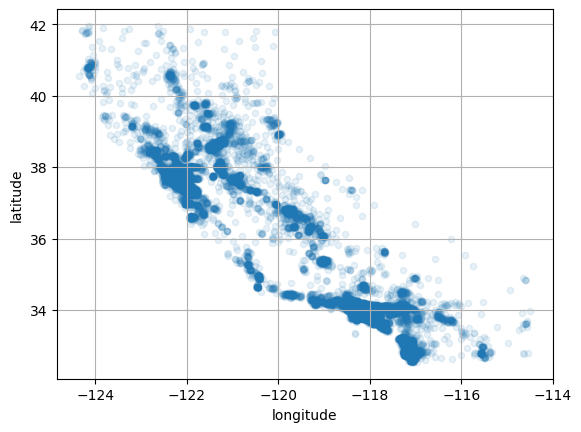

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.1)
plt.show()


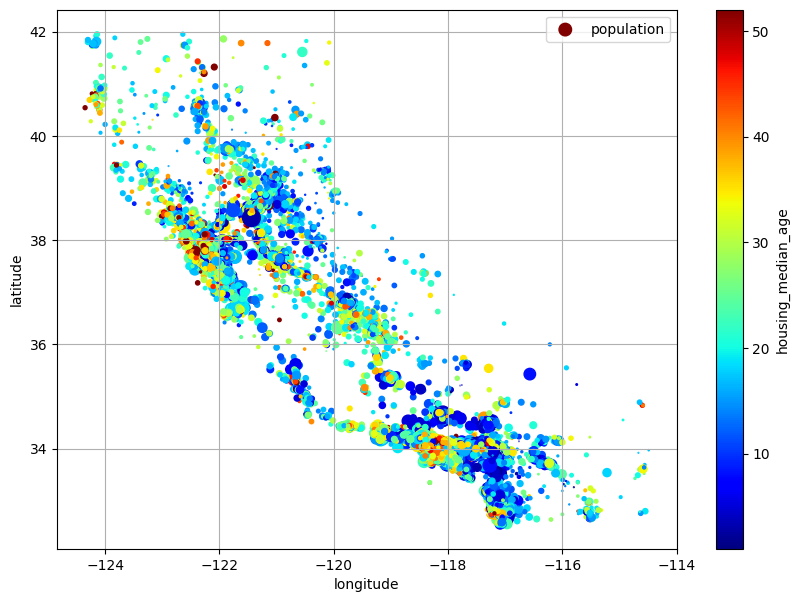

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
 s=housing["population"] / 100, label="population",
 c="housing_median_age", cmap="jet", colorbar=True,
 legend=True, sharex=False, figsize=(10, 7))
plt.show()


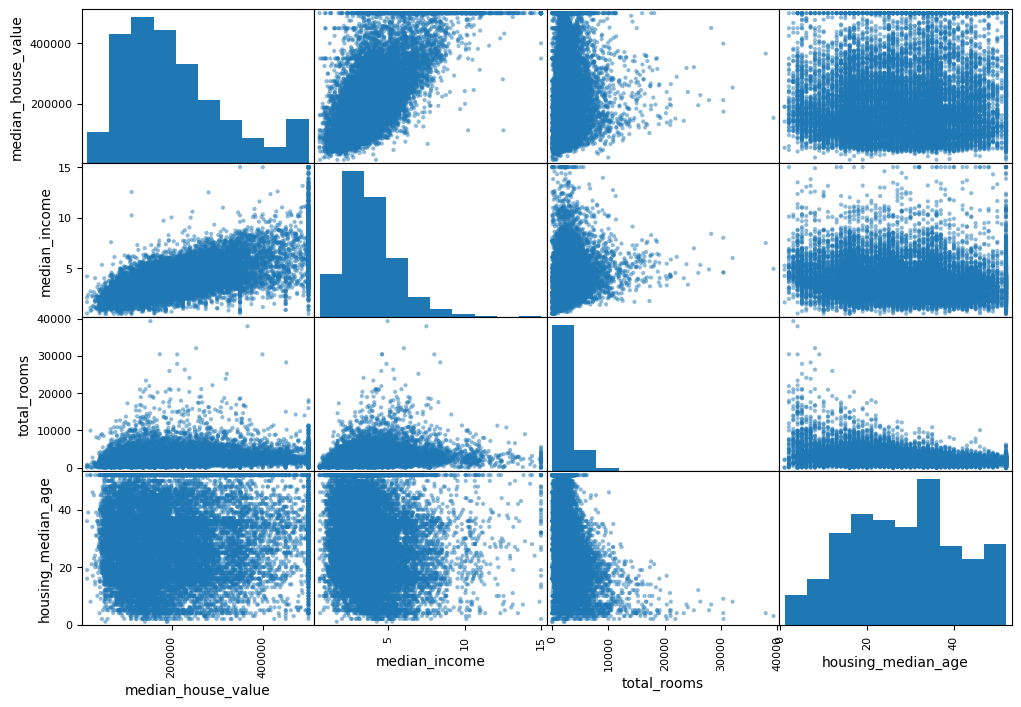

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
 "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

In [ ]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [ ]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["bedrooms_ratio"].sort_values(ascending=False)

,bedrooms_ratio
bedrooms_ratio,1.000000
housing_median_age,0.139119
total_bedrooms,0.089931
longitude,0.087802
households,0.072046
population,0.042698
people_per_house,-0.007122
latitude,-0.108871
total_rooms,-0.183273
median_house_value,-0.256397


In [ ]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

In [ ]:
housing_num = housing.select_dtypes(include=[np.number])

In [ ]:
imputer.fit(housing_num)


SimpleImputer(strategy='median')

In [ ]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
housing_num.median().values


array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [ ]:
X = imputer.transform(housing_num)


In [ ]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
 index=housing_num.index)

In [ ]:
housing_cat = housing[["ocean_proximity"]]
print(housing_cat)

      ocean_proximity
13096        NEAR BAY
14973       <1H OCEAN
3785           INLAND
14689          INLAND
20507      NEAR OCEAN
...               ...
14207       <1H OCEAN
13105          INLAND
19301      NEAR OCEAN
19121       <1H OCEAN
19888      NEAR OCEAN

[16512 rows x 1 columns]


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [ ]:
print(housing_cat_encoded[:10])

[[3.]
 [0.]
 [1.]
 [1.]
 [4.]
 [1.]
 [0.]
 [3.]
 [0.]
 [0.]]


In [ ]:
ordinal_encoder.categories_


[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [ ]:
print(ordinal_encoder)

OrdinalEncoder()


In [ ]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [ ]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [ ]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [ ]:
print(housing_num_min_max_scaled)
print(housing_num)

[[-0.60851927  0.11702128  1.         ... -0.80701754 -0.61433638
  -0.7794789 ]
 [ 0.21095335 -0.66170213  0.52941176 ... -0.91866029 -0.86708979
  -0.22929339]
 [-0.51926978  0.23617021  0.25490196 ... -0.93141946 -0.92458466
  -0.73336919]
 ...
 [ 0.47870183 -0.99148936 -0.52941176 ... -0.65513434 -0.71663244
  -0.50873781]
 [ 0.20689655 -0.6787234   0.41176471 ... -0.78873758 -0.68751167
  -0.49716556]
 [-0.60649087  0.08723404  0.68627451 ... -0.91669734 -0.92122457
  -0.61608805]]
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   
...          ...       ...        

In [ ]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)


In [ ]:
print(housing_num_std_scaled)

[[-1.42303652  1.0136059   1.86111875 ...  0.13746004  1.39481249
  -0.93649149]
 [ 0.59639445 -0.702103    0.90762971 ... -0.69377062 -0.37348471
   1.17194198]
 [-1.2030985   1.27611874  0.35142777 ... -0.78876841 -0.77572662
  -0.75978881]
 ...
 [ 1.25620853 -1.42870103 -1.23772062 ...  1.26829911  0.67913534
   0.1010487 ]
 [ 0.58639727 -0.73960483  0.66925745 ...  0.27356264  0.88286825
   0.14539615]
 [-1.41803793  0.94797769  1.22545939 ... -0.67915557 -0.75221898
  -0.31034135]]


In [ ]:
from sklearn.metrics.pairwise import rbf_kernel
age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)


In [ ]:
from sklearn.linear_model import LinearRegression
target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())
model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5] # pretend this is new data
scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

In [ ]:
from sklearn.compose import TransformedTargetRegressor
model = TransformedTargetRegressor(LinearRegression(),
 transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

In [ ]:
from sklearn.preprocessing import FunctionTransformer
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

In [ ]:
rbf_transformer = FunctionTransformer(rbf_kernel,
 kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])


In [ ]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
 kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])

In [ ]:
from sklearn.pipeline import Pipeline
num_pipeline = Pipeline([
 ("impute", SimpleImputer(strategy="median")),
 ("standardize", StandardScaler()),
])

In [ ]:
from sklearn.pipeline import make_pipeline
num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [ ]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)

In [ ]:
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [ ]:
df_housing_num_prepared = pd.DataFrame(
 housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
 index=housing_num.index)

In [ ]:
from sklearn.compose import ColumnTransformer
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]
cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"),OneHotEncoder(handle_unknown="ignore"))
preprocessing = ColumnTransformer([("num", num_pipeline, num_attribs),("cat", cat_pipeline, cat_attribs),])


In [ ]:
from sklearn.compose import make_column_selector, make_column_transformer
preprocessing = make_column_transformer(
 (num_pipeline, make_column_selector(dtype_include=np.number)),
 (cat_pipeline, make_column_selector(dtype_include=object)),
)


In [ ]:
housing_prepared = preprocessing.fit_transform(housing)

In [ ]:
print(housing_prepared)

[[-1.42303652  1.0136059   1.86111875 ...  0.          1.
   0.        ]
 [ 0.59639445 -0.702103    0.90762971 ...  0.          0.
   0.        ]
 [-1.2030985   1.27611874  0.35142777 ...  0.          0.
   0.        ]
 ...
 [ 1.25620853 -1.42870103 -1.23772062 ...  0.          0.
   1.        ]
 [ 0.58639727 -0.73960483  0.66925745 ...  0.          0.
   0.        ]
 [-1.41803793  0.94797769  1.22545939 ...  0.          0.
   1.        ]]


In [ ]:
housing_prepared = preprocessing.fit_transform(housing)
print(housing_prepared)

[[-1.42303652  1.0136059   1.86111875 ...  0.          1.
   0.        ]
 [ 0.59639445 -0.702103    0.90762971 ...  0.          0.
   0.        ]
 [-1.2030985   1.27611874  0.35142777 ...  0.          0.
   0.        ]
 ...
 [ 1.25620853 -1.42870103 -1.23772062 ...  0.          0.
   1.        ]
 [ 0.58639727 -0.73960483  0.66925745 ...  0.          0.
   0.        ]
 [-1.41803793  0.94797769  1.22545939 ...  0.          0.
   1.        ]]


In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7c4...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c4e345a35c0>)])),
                ('linearregression', LinearRegression())])

In [ ]:
housing_predictions = lin_reg.predict(housing)

In [ ]:
housing_predictions[:5].round(-2)

array([245100., 377600., 125700., 101500., 324100.])

In [ ]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [ ]:
from sklearn.metrics import root_mean_squared_error
lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

68796.4670140139

In [ ]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7c4...
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7c4e345a35c0>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [ ]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

In [ ]:
from sklearn.model_selection import cross_val_score
tree_rmses = -cross_val_score(tree_reg, housing, housing_labels,
scoring="neg_root_mean_squared_error", cv=10)

In [ ]:
pd.Series(tree_rmses).describe()

,0
count,10.000000
mean,66845.727286
std,2427.665650
min,63048.798317
25%,65680.328698
50%,66497.242619
75%,68548.906563
max,70551.932138


In [ ]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = make_pipeline(preprocessing,
 RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
 scoring="neg_root_mean_squared_error", cv=10)

In [ ]:
from sklearn.model_selection import GridSearchCV
full_pipeline = Pipeline([
 ("preprocessing", preprocessing),
 ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = [
 {'preprocessing__geo__n_clusters': [5, 8, 10],
 'random_forest__max_features': [4, 6, 8]},
 {'preprocessing__geo__n_clusters': [10, 15],
 'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
 scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7c4e345a35c0>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
 'random_forest__max_features': randint(low=2, high=20)}
rnd_search = RandomizedSearchCV(
 full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
 scoring='neg_root_mean_squared_error', random_state=42)
rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c4e34322f00>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c4e3456a600>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
final_model = rnd_search.best_estimator_ # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)


array([0.06, 0.06, 0.04, 0.01, 0.01, 0.01, 0.01, 0.19, 0.  , 0.02, 0.01,
       0.02, 0.01, 0.01, 0.01, 0.01, 0.02, 0.02, 0.  , 0.01, 0.01, 0.01,
       0.03, 0.01, 0.01, 0.01, 0.01, 0.01, 0.02, 0.02, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.02, 0.01, 0.02, 0.  , 0.01, 0.01, 0.01,
       0.02, 0.01, 0.01, 0.02, 0.02, 0.01, 0.  , 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

In [ ]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()
final_predictions = final_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse) # prints 41445.533268606625

41794.02754823782


In [ ]:
from scipy import stats
def rmse(squared_errors):
 return np.sqrt(np.mean(squared_errors))
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
 confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval


In [ ]:
import joblib
joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

First, you'll need to load the model back into memory using `joblib.load()`:

In [ ]:
import joblib

# Load the saved model
loaded_model = joblib.load("my_california_housing_model.pkl")
print("Model loaded successfully!")

Model loaded successfully!


Once loaded, you can use its `predict()` method on new data. Remember that the new data should have the same feature structure as the training data (i.e., the same columns in the same order, and similar preprocessing if necessary).

Let's use the first 5 rows of your test set (`X_test`) as an example of new data:

In [ ]:
# Take a few samples from X_test to simulate new data for prediction
some_new_data = X_test.iloc[:5]

# Make predictions using the loaded model
predictions_on_new_data = loaded_model.predict(some_new_data)

print("Predictions for the first 5 new data points:")
print(predictions_on_new_data.round(-2))

ValueError: Expected 2D array, got scalar array instead:
array=nan.
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

You can compare these predictions to the actual median house values (`y_test`) for these data points:

In [ ]:
print("Actual median house values for the first 5 new data points:")
print(y_test.iloc[:5].values)

Actual median house values for the first 5 new data points:
[397700. 202900. 310000. 314300. 187500.]
